
================ DATASET SHAPES ================

X_train Shape : (1200, 8)
X_test Shape  : (300, 8)
y_train Shape : (1200,)
y_test Shape  : (300,)

TRAINING : Logistic Regression

Accuracy  : 0.7733
Precision : 0.7129
Recall    : 0.6486
F1 Score  : 0.6792

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       189
           1       0.71      0.65      0.68       111

    accuracy                           0.77       300
   macro avg       0.76      0.75      0.75       300
weighted avg       0.77      0.77      0.77       300



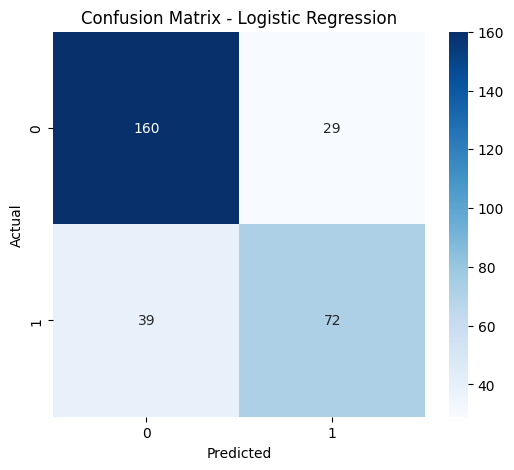

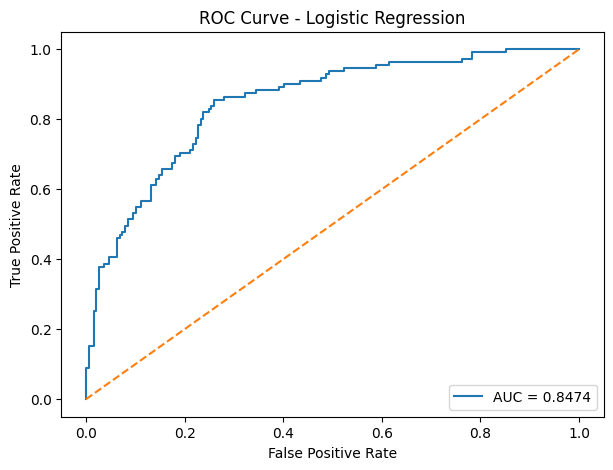


TRAINING : Random Forest

Accuracy  : 0.8633
Precision : 0.9268
Recall    : 0.6847
F1 Score  : 0.7876

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       189
           1       0.93      0.68      0.79       111

    accuracy                           0.86       300
   macro avg       0.88      0.83      0.84       300
weighted avg       0.87      0.86      0.86       300



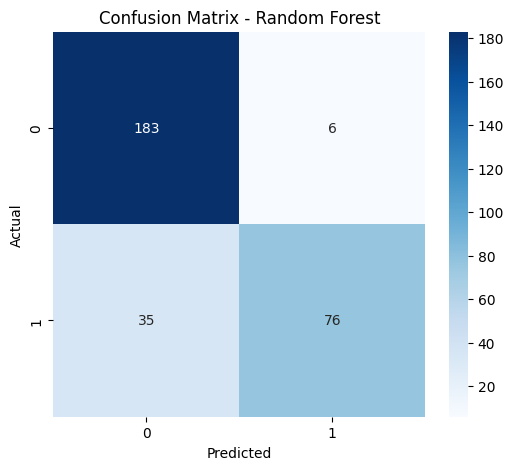

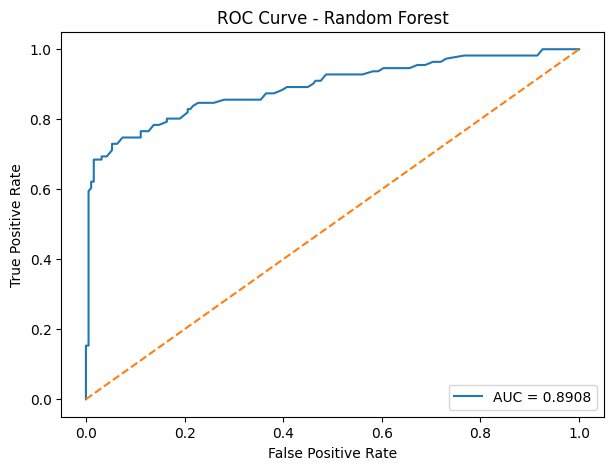


TRAINING : Support Vector Machine

Accuracy  : 0.7967
Precision : 0.7976
Recall    : 0.6036
F1 Score  : 0.6872

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       189
           1       0.80      0.60      0.69       111

    accuracy                           0.80       300
   macro avg       0.80      0.76      0.77       300
weighted avg       0.80      0.80      0.79       300



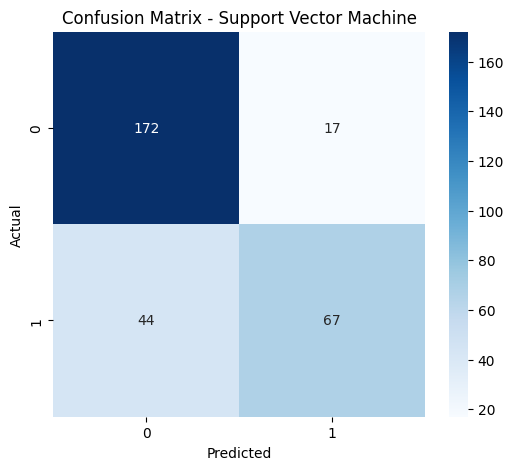

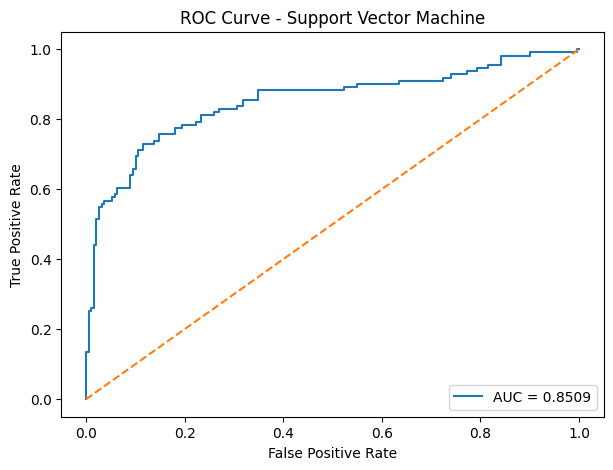


TRAINING : Gradient Boosting

Accuracy  : 0.8567
Precision : 0.8696
Recall    : 0.7207
F1 Score  : 0.7882

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       189
           1       0.87      0.72      0.79       111

    accuracy                           0.86       300
   macro avg       0.86      0.83      0.84       300
weighted avg       0.86      0.86      0.85       300



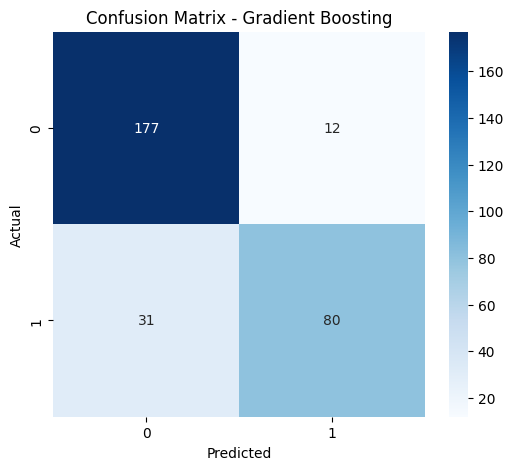

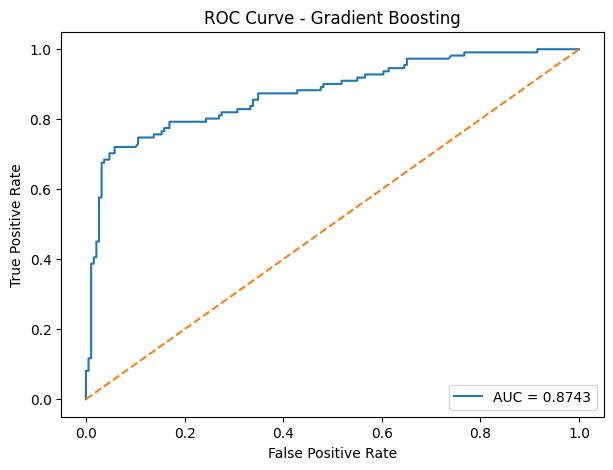


MODEL COMPARISON

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.773333   0.712871  0.648649  0.679245
1           Random Forest  0.863333   0.926829  0.684685  0.787565
2  Support Vector Machine  0.796667   0.797619  0.603604  0.687179
3       Gradient Boosting  0.856667   0.869565  0.720721  0.788177


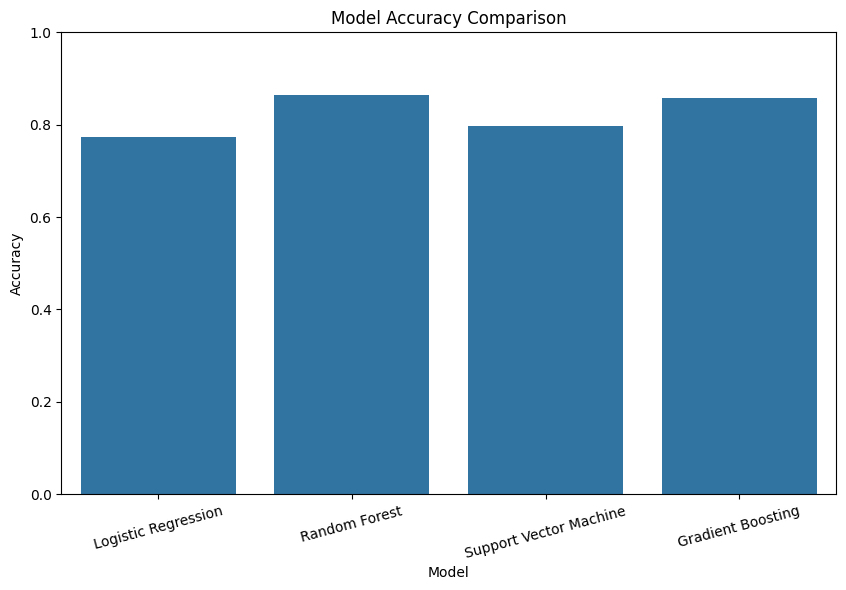


BEST MODEL

Best Model    : Random Forest
Best Accuracy : 0.8633

TOP IMPORTANT FEATURES

            Feature  Importance
6     AlcoholIntake    0.213153
2               BMI    0.198095
5  PhysicalActivity    0.172729
0               Age    0.172496
4       GeneticRisk    0.116604
1            Gender    0.072489
3           Smoking    0.054433
7     CancerHistory    0.000000


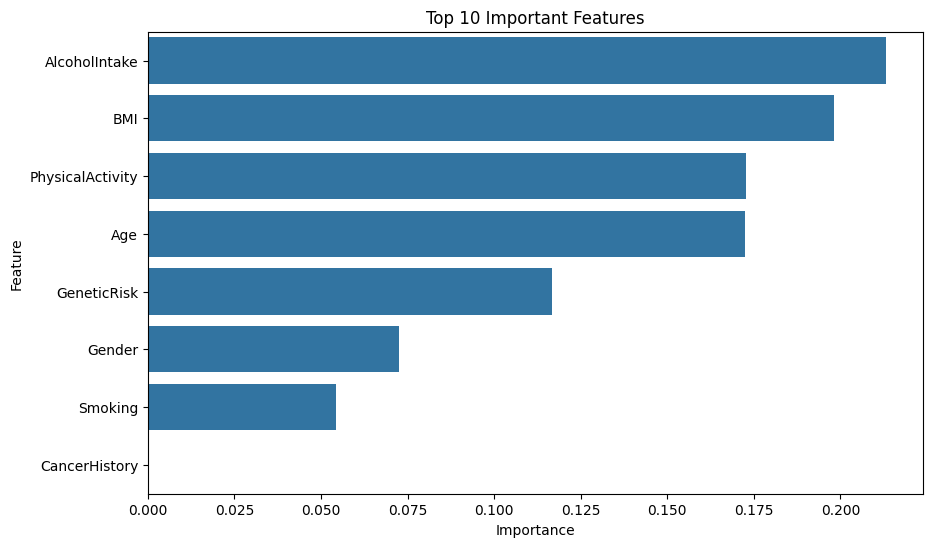


BEST MODEL SAVED SUCCESSFULLY

IMPORTANT:
Save scaler separately from feature engineering notebook.

ULTRA PROFESSIONAL MODEL TRAINING COMPLETED


In [ ]:
# ==========================================================
# ULTRA PROFESSIONAL MODEL TRAINING PIPELINE
# CANCER PREDICTION PROJECT
# ==========================================================

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Save Model
import joblib

# ==========================================================
# LOAD PREPROCESSED DATA
# ==========================================================

X_train = pd.read_csv("../dataset/X_train_scaled.csv")

X_test = pd.read_csv("../dataset/X_test_scaled.csv")

y_train = pd.read_csv("../dataset/y_train.csv")

y_test = pd.read_csv("../dataset/y_test.csv")

# Convert target columns to Series
y_train = y_train.squeeze()

y_test = y_test.squeeze()

# ==========================================================
# DATASET SHAPES
# ==========================================================

print("\n================ DATASET SHAPES ================\n")

print("X_train Shape :", X_train.shape)

print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)

print("y_test Shape  :", y_test.shape)

# ==========================================================
# INITIALIZE MODELS
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# ==========================================================
# TRAINING & EVALUATION
# ==========================================================

results = []

best_accuracy = 0

best_model = None

best_model_name = ""

# ==========================================================
# LOOP THROUGH MODELS
# ==========================================================

for model_name, model in models.items():

    print("\n================================================")

    print(f"TRAINING : {model_name}")

    print("================================================")

    # ------------------------------------------------------
    # TRAIN MODEL
    # ------------------------------------------------------

    model.fit(X_train, y_train)

    # ------------------------------------------------------
    # PREDICTIONS
    # ------------------------------------------------------

    y_pred = model.predict(X_test)

    # ------------------------------------------------------
    # PROBABILITY PREDICTIONS
    # ------------------------------------------------------

    y_prob = model.predict_proba(X_test)[:,1]

    # ------------------------------------------------------
    # EVALUATION METRICS
    # ------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # ------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1
    })

    # ------------------------------------------------------
    # PRINT METRICS
    # ------------------------------------------------------

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    # ------------------------------------------------------
    # CLASSIFICATION REPORT
    # ------------------------------------------------------

    print("\nCLASSIFICATION REPORT\n")

    print(classification_report(y_test, y_pred))

    # ------------------------------------------------------
    # CONFUSION MATRIX
    # ------------------------------------------------------

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ------------------------------------------------------
    # ROC CURVE
    # ------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend(loc="lower right")

    plt.show()

    # ------------------------------------------------------
    # SAVE BEST MODEL
    # ------------------------------------------------------

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = model_name

# ==========================================================
# MODEL COMPARISON TABLE
# ==========================================================

results_df = pd.DataFrame(results)

print("\n================================================")

print("MODEL COMPARISON")

print("================================================\n")

print(results_df)

# ==========================================================
# VISUALIZE MODEL COMPARISON
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

print("\n================================================")

print("BEST MODEL")

print("================================================\n")

print(f"Best Model    : {best_model_name}")

print(f"Best Accuracy : {best_accuracy:.4f}")

# ==========================================================
# FEATURE IMPORTANCE
# (ONLY FOR TREE-BASED MODELS)
# ==========================================================

if hasattr(best_model, 'feature_importances_'):

    feature_importance = pd.DataFrame({

        'Feature': X_train.columns,

        'Importance': best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
    )

    print("\nTOP IMPORTANT FEATURES\n")

    print(feature_importance.head(10))

    # ------------------------------------------------------
    # FEATURE IMPORTANCE PLOT
    # ------------------------------------------------------

    plt.figure(figsize=(10,6))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_importance.head(10)
    )

    plt.title("Top 10 Important Features")

    plt.show()

# ==========================================================
# SAVE BEST MODEL
# ==========================================================

joblib.dump(
    best_model,
    "../models/best_cancer_model.pkl"
)

print("\nOPTIMAL MODEL SAVED SUCCESSFULLY")

# ==========================================================
# FINAL MESSAGE
# ==========================================================

print("\n=======================")

print(" MODEL TRAINING COMPLETED")

print("=========================")